In [1]:
import torch
import pandas as pd
import numpy as np
import random
from pyfaidx import Fasta

import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [2]:
# functions

def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence


def upper_triangular_to_vector_skip_two_diagonals(matrix):
    """
    Extracts the upper triangular part of a square matrix (excluding the first two diagonals) 
    and transforms it into a vector.
    
    Parameters:
        matrix (np.ndarray): A 2D numpy matrix of shape (512, 512).
        
    Returns:
        np.ndarray: A 1D array containing the upper triangular elements (excluding the first two diagonals).
    """
    if matrix.shape != (512, 512):
        raise ValueError("Input matrix must be of shape (512, 512).")
    
    # Extract the upper triangular part excluding the first two diagonals
    upper_triangular_vector = matrix[np.triu_indices(512, k=2)]
    
    return upper_triangular_vector


def fragment_indices_in_upper_triangular(matrix_size=512, fragment_mask=None):
    """
    Given a binary mask for a fragment in a (448, 448) matrix, find the corresponding indices 
    within the upper triangular output vector (excluding the first two diagonals).

    Parameters:
        matrix_size (int): The size of the square matrix (default: 448).
        fragment_mask (np.ndarray): A boolean mask of shape (448, 448) marking the fragment.

    Returns:
        np.ndarray: Indices in the upper triangular vector corresponding to the fragment.
    """
    if fragment_mask.shape != (matrix_size, matrix_size):
        raise ValueError("Fragment mask must be of shape (448, 448).")

    # Get the upper triangular indices skipping two diagonals
    row_indices, col_indices = np.triu_indices(matrix_size, k=2)
    
    # Identify which of these indices are in the fragment
    selected_indices = np.where(fragment_mask[row_indices, col_indices])[0]
    
    return selected_indices


def store_tower_output(ohe_sequence, model, path):
    x = model.conv_block_1(ohe_sequence)
    x = model.conv_tower(x)
    # save the tensor
    torch.save(x, path)
    torch.cuda.empty_cache()


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1129579/ipykernel_1829742/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [5]:
FOLD = 2

In [6]:
df = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold{FOLD}_selected_genomic_windows_centered.tsv", sep="\t")

In [7]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [8]:
def create_flame_mask(shape=(512, 512), center=None, flame_width=3, value=0.5):
    """
    Creates a flame/stripe-shaped mask: vertical and horizontal lines forming an 'L' shape.
    
    Parameters:
    - shape: (rows, cols) of the mask
    - center: (row, col) center of the flame (defaults to middle of matrix)
    - flame_width: total width of the stripe (must be odd or even)
    - value: the value to fill in the stripe
    
    Returns:
    - mask: 2D numpy array with the flame mask
    """
    H, W = shape
    if center is None:
        half_r, half_c = H // 2, W // 2
    else:
        half_r, half_c = center

    half_flame_width = flame_width // 2
    mask = np.zeros((H, W), dtype=float)

    # Vertical stripe (top half of map)
    mask[:half_r, half_c - half_flame_width:half_c + half_flame_width] = value

    # Horizontal stripe (left half of map)
    mask[half_r - half_flame_width:half_r + half_flame_width, :half_c] = value

    return mask

In [9]:
mask = create_flame_mask(flame_width=3, value=0.5)

In [10]:
import matplotlib.pyplot as plt

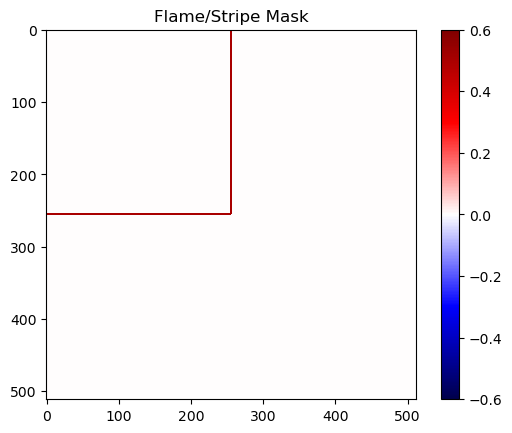

In [11]:
plt.imshow(mask, cmap='seismic', interpolation='nearest', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('Flame/Stripe Mask')
plt.show()

In [12]:
fountain_mask_vector = upper_triangular_to_vector_skip_two_diagonals(mask)
fountain_mask_vector_tensor = torch.tensor(fountain_mask_vector).to(device)

In [13]:
fragment_bool_mask  = mask != 0

In [14]:
size = 512

In [15]:
flame_mask_indices = fragment_indices_in_upper_triangular(matrix_size=size, fragment_mask=fragment_bool_mask)
flame_mask_indices_tensor = torch.tensor(flame_mask_indices)

In [ ]:
# torch.save(flame_mask_indices_tensor, "/scratch1/smaruj/generate_genomic_flame/flame_indices.pt")

In [16]:
for row in df.itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    sequence = genome[row.chrom][pred_start:pred_end]
    
    X = one_hot_encode_sequence(sequence)
    X_tensor = torch.tensor(X)
    # torch.save(X_tensor, f"/scratch1/smaruj/genomic_insertion_loci/ohe_X/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_X.pt")

    # store_tower_output(X_tensor, model, f"/scratch1/smaruj/genomic_insertion_loci/tower_outputs/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_tower_out.pt")
    
    model.eval()
    with torch.no_grad():
        y = model(X_tensor)
    
    y = y.to(device)
    # summing up map + mask
    y_bar = y[0, 0, :] + fountain_mask_vector_tensor
    y_bar = y_bar.unsqueeze(0).unsqueeze(0)
    
    # replacing values of map with the mask
    # y_bar = y.to(device).clone()
    # masked_values = boundary_mask_vector_tensor[boundary_mask_indices_tensor].float()
    # y_bar[0, 0, boundary_mask_indices_tensor] = masked_values.to(device)
    
    torch.save(y_bar, f"/scratch1/smaruj/generate_genomic_flame/targets_0.5/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_target.pt")
    # torch.save(y, f"/scratch1/smaruj/genomic_insertion_loci/genomic_targets/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_target.pt")